## Exploration and Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from hmmlearn import hmm

df = pd.read_csv('weatherHistory.csv')
print(df.head())



   ----------------- ---------------------- 3/7 [bleach]
   ----------------- ---------------------- 3/7 [bleach]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------- ----------------- 4/7 [kagglesdk]
   ---------------------------- ----------- 5/7 [kaggle]
   ---------------------------------- ----- 6/7 [opendatasets]
   ---------------------------------------- 7/7 [opendatasets]

Note: you may need to restart the kernel to use updated packages.
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle username:Your Kaggle username:Your Kaggle Key:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/budincsevity/szeged-weather


100%|██████████| 2.23M/2.23M [00:00<00:00, 2.35MB/s]

"\ndf = pd.read_csv('weatherHistory.csv')\nprint(df.head())\n"

In [34]:
# Preprocess Date
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df = df.sort_values('Formatted Date')

In [35]:
# Basic Info
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df = df.drop(columns=['Loud Cover'])


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 96453 entries, 2880 to 89732
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   Formatted Date            96453 non-null  datetime64[ns, UTC]
 1   Summary                   96453 non-null  object             
 2   Precip Type               95936 non-null  object             
 3   Temperature (C)           96453 non-null  float64            
 4   Apparent Temperature (C)  96453 non-null  float64            
 5   Humidity                  96453 non-null  float64            
 6   Wind Speed (km/h)         96453 non-null  float64            
 7   Wind Bearing (degrees)    96453 non-null  float64            
 8   Visibility (km)           96453 non-null  float64            
 9   Loud Cover                96453 non-null  float64            
 10  Pressure (millibars)      96453 non-null  float64            
 11  Da

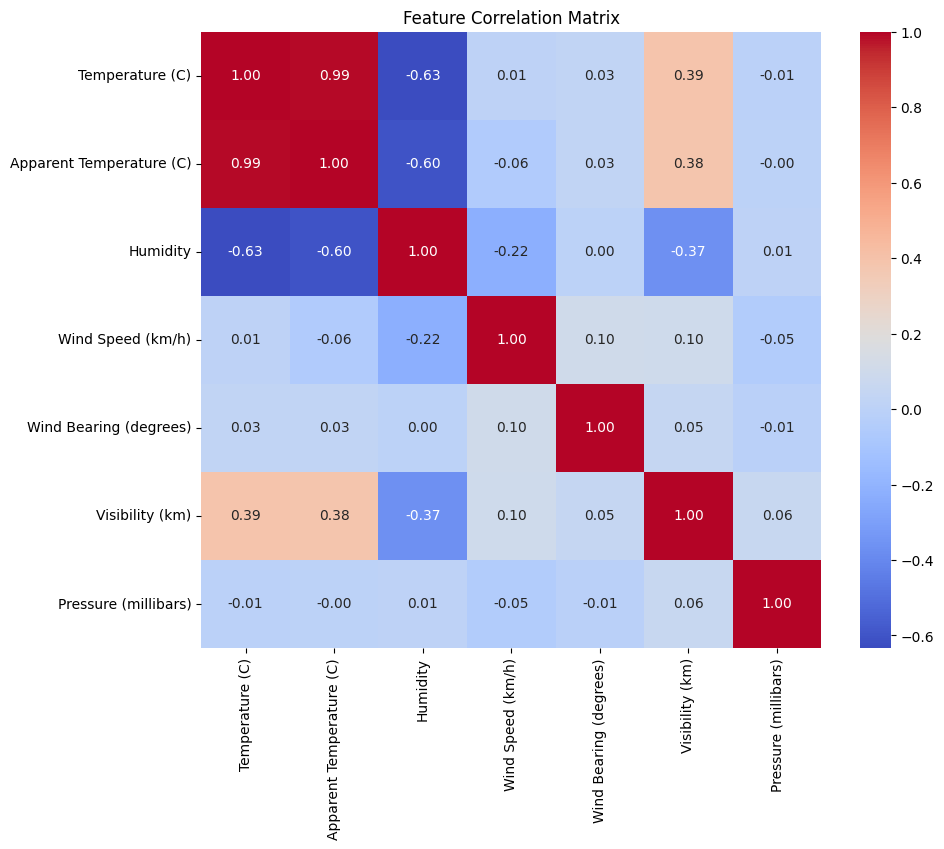

In [36]:
# Feature correlations
for feature in df.columns:
    if feature not in ['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary']:
        numeric_df = df.select_dtypes(include=[np.number])
        corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

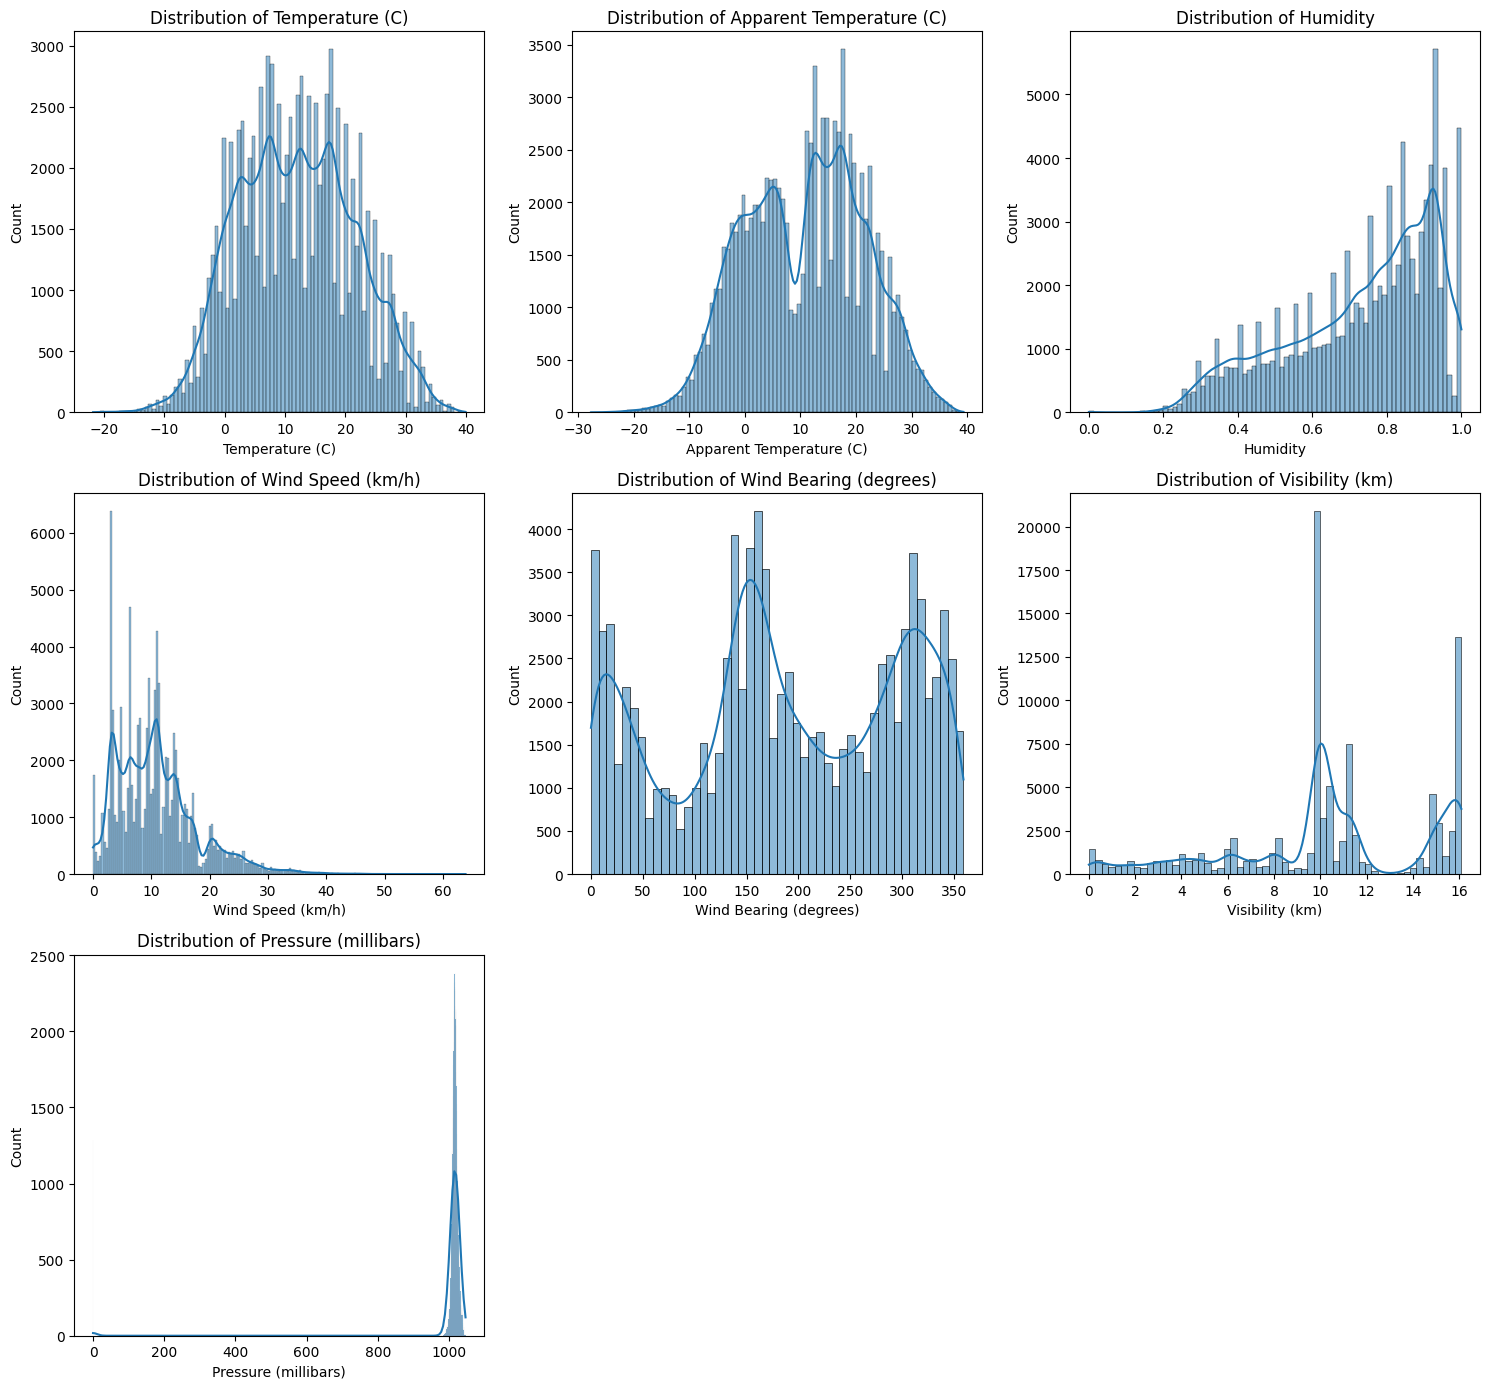

In [37]:
# Distributions
cols = numeric_df.columns
n_cols = len(cols)

plt.figure(figsize=(15, n_cols * 2))
for i, col in enumerate(cols):
    plt.subplot((n_cols // 3) + 1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In [38]:
# Select relevant features
features = ['Temperature (C)', 'Humidity', 'Pressure (millibars)']
X = df[features].values


In [39]:
import numpy as np
from sklearn.preprocessing import StandardScaler
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# Training
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100)
model.fit(X_scaled)

C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^

GaussianHMM(covariance_type='full', n_components=3, n_iter=100)

In [41]:
# Predict States
hidden_states = model.predict(X_scaled)
df['Hidden_State'] = hidden_states

In [42]:
# Analyze Results
print("\nTransition Matrix:")
print(model.transmat_)

print("\nState Means (Scaled):")
print(model.means_)



Transition Matrix:
[[0.98310256 0.00963581 0.00726163]
 [0.35803257 0.3734472  0.26852023]
 [0.00774725 0.00727246 0.98498029]]

State Means (Scaled):
[[-0.76915404  0.34566035  0.12670665]
 [-0.12844957 -0.02478424 -8.57691686]
 [ 0.80727913 -0.36051026  0.10498252]]


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score
from hmmlearn import hmm # Ensure hmmlearn.hmm is imported as hmm

sample_size = 5000

# Use the 'hidden_states' from the previously trained 'model' for sampling
# This ensures y_sample corresponds to the original model's predictions
if len(X_scaled) > sample_size:
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_sample = X_scaled[indices]
    y_sample_for_final_score = hidden_states[indices]
else:
    X_sample = X_scaled
    y_sample_for_final_score = hidden_states

for i in range(2, 7):
    # Use a different variable name for the HMM instance to avoid overwriting the module 'hmm'
    current_hmm_model = hmm.GaussianHMM(n_components=i, random_state=42)
    current_hmm_model.fit(X_scaled)
    y_hmm_predictions = current_hmm_model.predict(X_scaled)
    print(f"Hidden States: {i}")
    print("Silhouette Score (HMM) :", silhouette_score(X_scaled, y_hmm_predictions))
    # Adjusted Rand Index requires true labels (y), which are not available in this context.
    # print("Adjusted Rand Index (HMM) :", adjusted_rand_score(y, y_hmm_predictions))
    print("BIC du HMM :", current_hmm_model.bic(X_scaled))
    print("AIC du HMM :", current_hmm_model.aic(X_scaled))
    print("---" * 16)


print(f"Nombre de hidden states (from initial model): {model.n_components}") # Refers to the 'model' trained earlier (n_components=3)
print("Silhouette Score (sample from initial model) :", silhouette_score(X_sample, y_sample_for_final_score))